In [1]:
#importing libraries
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch.nn.functional as F

In [3]:
#root data directory path
data_dir = r"C:\Users\Arve\PycharmProjects\Signature recognition system\notebook\data"

In [5]:
class_name = os.listdir(data_dir)

In [7]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torchvision.utils import make_grid
from torchvision import transforms as T,datasets

Checking cuda availablity


In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:{}".format(device))

Device:cpu


Transforming the data

In [23]:
data_transform = T.Compose([
                             T.Resize(size=(224,224)), # Resizing the image to be 224 by 224
                             T.RandomRotation(degrees=(-20,+20)), #Randomly Rotate Images by +/- 20 degrees, Image augmentation for each epoch
                             T.ToTensor(), #converting the dimension from (height,weight,channel) to (channel,height,weight) convention of PyTorch
                             T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]) # Normalize by 3 means 3 StD's of the image net, 3 channels

])

In [25]:
data = datasets.ImageFolder(data_dir, transform=data_transform)
total_count = len(data)

In [27]:
total_count

3711

In [29]:
data.classes

['forged_signatures_archive', 'original_signatures_archive']

Splitting the data

In [31]:
train_count = int(0.6 * total_count) 
valid_count = int(0.3 * total_count)
test_count = total_count - train_count - valid_count
train_data, val_data, test_data = torch.utils.data.random_split(data, (train_count, valid_count, test_count))

In [33]:
len(train_data.indices)


2226

In [35]:

len(test_data.indices)

372

In [37]:

len(val_data.indices)

1113


Defining some functions

In [54]:
def show_image(image,label,get_denormalize = True):
    
    image = image.permute(1,2,0)
    mean = torch.FloatTensor([0.485, 0.456, 0.406])
    std = torch.FloatTensor([0.229, 0.224, 0.225])
    
    if get_denormalize == True:
        image = image*std + mean
        image = np.clip(image,0,1)
        plt.imshow(image)
        plt.title(label)
        
    else: 
        plt.imshow(image)
        plt.title(label)


def accuracy(y_pred,y_true):
    y_pred = F.softmax(y_pred,dim = 1)
    top_p,top_class = y_pred.topk(1,dim = 1)
    equals = top_class == y_true.view(*top_class.shape)
    return torch.mean(equals.type(torch.FloatTensor))

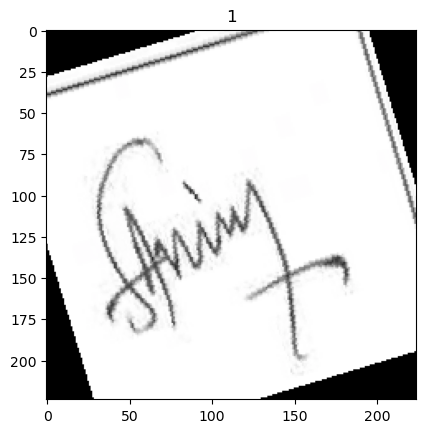

In [56]:
img, label = train_data[0]
show_image(img,label)

Data Loaders

In [112]:

trainloader = DataLoader(train_data, batch_size=32, shuffle=True)
print("No. of batches in trainloader:{}".format(len(trainloader))) 
print("No. of Total examples:{}".format(len(trainloader.dataset)))

validationloader = DataLoader(val_data, batch_size=32, shuffle=True)
print("No. of batches in validationloader:{}".format(len(validationloader)))  
print("No. of Total examples:{}".format(len(validationloader.dataset)))

testloader = DataLoader(test_data ,batch_size=32, shuffle=False)
print("No. of batches in testloader:{}".format(len(testloader))) 
print("No. of Total examples:{}".format(len(testloader.dataset)))


No. of batches in trainloader:70
No. of Total examples:2226
No. of batches in validationloader:35
No. of Total examples:1113
No. of batches in testloader:12
No. of Total examples:372


MOdel

In [114]:

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import models
import torchvision.transforms as transforms

In [116]:
model = models.resnet34(pretrained=True)

In [118]:
model.fc = nn.Sequential(
    nn.Dropout(0.1),
    nn.Linear(model.fc.in_features, len(class_name))
)
model = model.to(device)
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3, momentum=0.9)


In [120]:
def train(model, criterion, optimizer, train_dataloader, test_dataloader):

    total_train_loss = 0
    total_test_loss = 0
    
    model.train()
    with tqdm(train_dataloader, unit='batch', leave=False) as pbar:
        pbar.set_description(f'training')
        for images, idxs in pbar:
            images = images.to(device, non_blocking=True)
            idxs = idxs.to(device, non_blocking=True)
            output = model(images)

            loss = criterion(output, idxs)
            total_train_loss += loss.item()

            loss.backward()
            optimizer.step()
            optimizer.zero_grad(set_to_none=True)

    model.eval()
    with tqdm(test_dataloader, unit='batch', leave=False) as pbar:
        pbar.set_description(f'testing')
        for images, idxs in pbar:
            images = images.to(device, non_blocking=True)
            idxs = idxs.to(device, non_blocking=True)

            output = model(images)
            loss = criterion(output, idxs)
            total_test_loss += loss.item()

    train_acc = total_train_loss / len(train_data)
    test_acc = total_test_loss / len(val_data)
    print(f'Train loss: {train_acc:.4f} Test loss: {test_acc:.4f} ')

In [122]:

%%time
epochs=5
for i in range(epochs):
    print(f"Epoch {i+1}/{epochs}")
    train(model, criterion, optimizer, trainloader, validationloader)

Epoch 1/5


Train loss: 0.0227 Test loss: 0.0224 
Epoch 2/5


Train loss: 0.0211 Test loss: 0.0237 
Epoch 3/5


Train loss: 0.0186 Test loss: 0.0198 
Epoch 4/5


Train loss: 0.0168 Test loss: 0.0189 
Epoch 5/5


Train loss: 0.0135 Test loss: 0.0164 
CPU times: total: 2h 32min 7s
Wall time: 19min 48s


Model saving

In [127]:
path = data_dir = r"C:\Users\Arve\PycharmProjects\Signature recognition system\notebook\model.pt"
torch.save(model, path)

In [129]:
pwd

'C:\\Users\\Arve\\PycharmProjects\\Signature recognition system\\notebook'

Loading torch model

In [132]:
#model class must be defined in a path
model = torch.load(path)
model.eval()

C:\Users\Arve\AppData\Local\Temp\ipykernel_41960\3827643922.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load(path)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

Model Evalution

In [134]:
def evaluate(model, criterion, optimizer, test_dataloader):
    total_test_loss = 0

    model.eval()
    with tqdm( test_dataloader, unit="batch", leave= False) as pbar:
        pbar.set_description(f'testing')
        for images, idxs in pbar:
            images = images.to(device, non_blocking = True)
            idxs = idxs.to(device, non_blocking=True)

            output = model(images)
            loss = criterion(output, idxs)
            total_test_loss += loss.item()

        test_acc = total_test_loss / len(val_data)
        print(f'Test loss: {test_acc: .4f}')

In [136]:
evaluate(model, criterion, optimizer, testloader)

Test loss:  0.0049


Prediction

In [144]:
label_names = data.classes
label_names

['forged_signatures_archive', 'original_signatures_archive']

In [154]:
from PIL import Image
image =Image.open(r'C:\Users\Arve\PycharmProjects\Signature recognition system\notebook\data\original_signatures_archive\1-001_01.jpg')
preprocess = transforms.Compose([
    transforms.Resize(size = (224, 224)),
    transforms.Grayscale(3),
    transforms.ToTensor()
])

image = preprocess(image)
image = image[:3]
 #Conver the image to a Pytorch tensor and sent it to the device
image =image.unsqueeze(0).to(device)
# make the predictoin
with torch.no_grad():
    logits = model(image)
    probs = torch. softmax(logits, dim=1)
    pred_label=torch.argmax(probs, dim=1)

#print the prediction
print(f'pridiction label: {pred_label.item()}')

# Map the predicted label to the corresponding class name
predicted_class_name = label_names[pred_label.item()]

# Print the predicted class name
print(f'Predicted class name: {predicted_class_name}')

pridiction label: 1
Predicted class name: original_signatures_archive
